# Comparando o SARSA e o Q-Learning

In [1]:
import gymnasium as gym
import numpy as np
from tqdm.notebook import trange
import random
import matplotlib.pyplot as plt


In [2]:
def epsilon_greedy_policy(Qtable, state, epsilon, action_space):
    # Gere aleatoriamente um número entre 0 e 1
    random_int = random.uniform(0,1)
    # Se random é maior que epsilon --> exploitation (fazer uma ação baseada na experiência)
    if random_int > epsilon:
        # Execute a ação com o valor mais alto dado um estado
        # np.argmax can be useful here
        action = np.argmax(Qtable[state])
      # else --> exploration (fazer uma ação aleatória para avaliar novos ações)
    else:
       action = action_space.sample()

    return action

In [3]:
def run_episode_qlearning(env, Qtable, epsilon, learning_rate, gamma, max_steps):
    """
    Executa um episódio completo usando Q-Learning

    Retorna:
        total_reward: soma das recompensas do episódio
        success: True se atingiu o objetivo, False caso contrário
        steps: número de passos dados
    """
    state, info = env.reset()
    total_reward = 0
    done = False
    steps = 0

    for step in range(max_steps):
        # Escolhe ação usando epsilon-greedy
        action = epsilon_greedy_policy(Qtable, state, epsilon, env.action_space)

        # Executa ação
        new_state, reward, done, truncated, info = env.step(action)

        # Atualização Q-Learning (usa max Q-value do próximo estado)
        Qtable[state][action] = Qtable[state][action] + learning_rate * (
            reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action]
        )

        total_reward += reward
        steps += 1

        if done or truncated:
            break

        state = new_state

    # Sucesso se recebeu recompensa positiva (depende do ambiente)
    success = done and not truncated


    return total_reward, success, steps

In [4]:

def run_episode_sarsa(env, Qtable, epsilon, learning_rate, gamma, max_steps):
    """
    Executa um episódio completo usando SARSA

    Retorna:
        total_reward: soma das recompensas do episódio
        success: True se atingiu o objetivo, False caso contrário
        steps: número de passos dados
    """
    state, info = env.reset()
    action = epsilon_greedy_policy(Qtable, state, epsilon, env_cliff.action_space)  # Primeira ação

    total_reward = 0
    done = False
    steps = 0

    for step in range(max_steps):
        # Executa ação
        new_state, reward, done, truncated, info = env.step(action)

        # Escolhe próxima ação ANTES de atualizar
        new_action = epsilon_greedy_policy(Qtable, new_state, epsilon, env_cliff.action_space)

        # Atualização SARSA (usa Q-value da ação escolhida, não max)
        Qtable[state][action] = Qtable[state][action] + learning_rate * (
            reward + gamma * Qtable[new_state][new_action] - Qtable[state][action]
        )

        total_reward += reward
        steps += 1

        if done or truncated:
            break

        state = new_state
        action = new_action  # Usa a ação já escolhida

    success = done and not truncated

    return total_reward, success, steps

In [5]:
def train_and_compare(env, n_episodes=10000, window_size=100):
    """
    Treina e compara Q-Learning vs SARSA

    Args:
        env: ambiente Gym
        n_episodes: número de episódios de treinamento
        window_size: janela para calcular médias móveis

    Returns:
        dict com resultados e Q-Tables
    """

    # Hiperparâmetros
    # ========== HIPERPARÂMETROS AJUSTADOS ==========
    learning_rate = 0.1        # Menor para aprendizado mais estável
    gamma = 0.99               # Maior para valorizar recompensas futuras
    max_epsilon = 1.0
    min_epsilon = 0.01         # Menor mínimo para mais exploração
    decay_rate = 0.00005       # MUITO MAIS LENTO! (era 0.0005)
    max_steps = 200            # Mais passos permitidos

    # Inicializa Q-Tables
    state_space = env.observation_space.n
    action_space = env.action_space.n

    Qtable_ql = np.zeros((state_space, action_space))
    Qtable_sarsa = np.zeros((state_space, action_space))

    # Arrays para armazenar métricas
    rewards_ql = []
    rewards_sarsa = []
    steps_ql = []
    steps_sarsa = []
    success_ql = []
    success_sarsa = []

    print("Treinando ambos os algoritmos...")

    for episode in trange(n_episodes):
        # Calcula epsilon atual
        epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

        # Episódio Q-Learning
        reward_ql, success_ql_ep, steps_ql_ep = run_episode_qlearning(
            env, Qtable_ql, epsilon, learning_rate, gamma, max_steps
        )
        rewards_ql.append(reward_ql)
        steps_ql.append(steps_ql_ep)
        success_ql.append(1 if success_ql_ep else 0)

        # Episódio SARSA
        reward_sarsa, success_sarsa_ep, steps_sarsa_ep = run_episode_sarsa(
            env, Qtable_sarsa, epsilon, learning_rate, gamma, max_steps
        )
        rewards_sarsa.append(reward_sarsa)
        steps_sarsa.append(steps_sarsa_ep)
        success_sarsa.append(1 if success_sarsa_ep else 0)

    # Calcula médias móveis
    def moving_average(data, window):
        return np.convolve(data, np.ones(window)/window, mode='valid')

    rewards_ql_smooth = moving_average(rewards_ql, window_size)
    rewards_sarsa_smooth = moving_average(rewards_sarsa, window_size)

    success_ql_smooth = moving_average(success_ql, window_size)
    success_sarsa_smooth = moving_average(success_sarsa, window_size)

    # Plota resultados
    plot_comparison_results(
        rewards_ql_smooth, rewards_sarsa_smooth,
        success_ql_smooth, success_sarsa_smooth,
        window_size
    )

    # Retorna resultados
    return {
        'Qtable_ql': Qtable_ql,
        'Qtable_sarsa': Qtable_sarsa,
        'rewards_ql': rewards_ql,
        'rewards_sarsa': rewards_sarsa,
        'success_ql': success_ql,
        'success_sarsa': success_sarsa
    }


def plot_comparison_results(rewards_ql, rewards_sarsa, success_ql, success_sarsa, window_size):
    """Plota gráficos de comparação entre Q-Learning e SARSA"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    episodes = np.arange(len(rewards_ql))

    # Gráfico 1: Recompensas
    ax1.plot(episodes, rewards_ql, label='Q-Learning', linewidth=2, alpha=0.8)
    ax1.plot(episodes, rewards_sarsa, label='SARSA', linewidth=2, alpha=0.8)
    ax1.set_xlabel('Episódios', fontsize=12)
    ax1.set_ylabel('Recompensa Média', fontsize=12)
    ax1.set_title(f'Recompensa por Episódio (Média Móvel: {window_size})', fontsize=14)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Gráfico 2: Taxa de Sucesso
    ax2.plot(episodes, success_ql * 100, label='Q-Learning', linewidth=2, alpha=0.8)
    ax2.plot(episodes, success_sarsa * 100, label='SARSA', linewidth=2, alpha=0.8)
    ax2.set_xlabel('Episódios', fontsize=12)
    ax2.set_ylabel('Taxa de Sucesso (%)', fontsize=12)
    ax2.set_title(f'Taxa de Sucesso (Média Móvel: {window_size})', fontsize=14)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Estatísticas finais
    print("\n" + "="*50)
    print("RESULTADOS FINAIS (últimos 1000 episódios):")
    print("="*50)
    print(f"Q-Learning:")
    print(f"  Recompensa média: {np.mean(rewards_ql[-1000:]):.2f}")
    print(f"  Taxa de sucesso: {np.mean(success_ql[-1000:]) * 100:.1f}%")
    print(f"\nSARSA:")
    print(f"  Recompensa média: {np.mean(rewards_sarsa[-1000:]):.2f}")
    print(f"  Taxa de sucesso: {np.mean(success_sarsa[-1000:]) * 100:.1f}%")
    print("="*50)


In [6]:
def evaluate_learned_policy(env, Qtable, n_eval=100):
    """
    Avalia a POLÍTICA APRENDIDA sem exploração
    """
    successes = 0
    total_rewards = []
    paths_taken = []

    for _ in range(n_eval):
        state, _ = env.reset()
        done = False
        total_reward = 0
        path = [state]
        steps = 0

        while not done and steps < 100:
            # SEM EXPLORAÇÃO! Apenas greedy
            action = np.argmax(Qtable[state])  # Sempre a melhor ação

            state, reward, done, truncated, _ = env.step(action)
            total_reward += reward
            path.append(state)
            steps += 1

            if done or truncated:
                break

        if done and not truncated:
            successes += 1

        total_rewards.append(total_reward)
        paths_taken.append(path)

    return {
        'success_rate': successes / n_eval * 100,
        'mean_reward': np.mean(total_rewards),
        'std_reward': np.std(total_rewards),
        'paths': paths_taken
    }



# Criando o ambiente CliffWalking

https://gymnasium.farama.org/environments/toy_text/cliff_walking/

Treinando ambos os algoritmos...


  0%|          | 0/50000 [00:00<?, ?it/s]

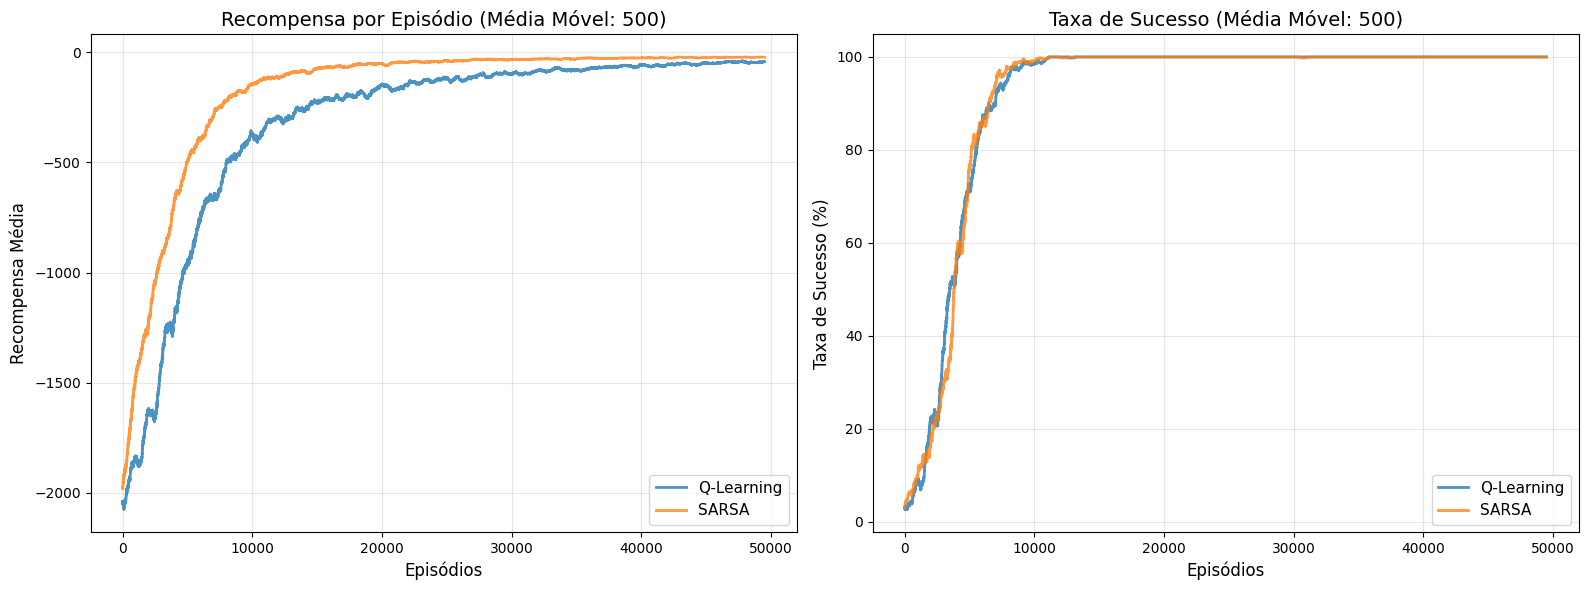


RESULTADOS FINAIS (últimos 1000 episódios):
Q-Learning:
  Recompensa média: -45.06
  Taxa de sucesso: 100.0%

SARSA:
  Recompensa média: -21.81
  Taxa de sucesso: 100.0%
AVALIAÇÃO DAS POLÍTICAS APRENDIDAS (SEM EXPLORAÇÃO)

Q-LEARNING:
  Taxa de sucesso: 100.0%
  Recompensa média: -13.00 ± 0.00

SARSA:
  Taxa de sucesso: 100.0%
  Recompensa média: -17.00 ± 0.00


In [7]:
# Cliff Walking é IDEAL para mostrar a diferença!
env_cliff = gym.make("CliffWalking-v1", render_mode="rgb_array")

# Q-Learning tende a encontrar o caminho ótimo (arriscado, perto do cliff)
# SARSA tende a ser mais conservador (caminho seguro, longe do cliff)

# Treina e compara
results_cliff = train_and_compare(env_cliff, n_episodes=50000, window_size=500)

# Acessa as Q-Tables treinadas
Qtable_qlearning = results_cliff['Qtable_ql']
Qtable_sarsa = results_cliff['Qtable_sarsa']

# Avalia ambos SEM exploração
print("AVALIAÇÃO DAS POLÍTICAS APRENDIDAS (SEM EXPLORAÇÃO)")

results_ql = evaluate_learned_policy(env_cliff, results_cliff['Qtable_ql'], 100)
results_sarsa = evaluate_learned_policy(env_cliff, results_cliff['Qtable_sarsa'], 100)

print(f"\nQ-LEARNING:")
print(f"  Taxa de sucesso: {results_ql['success_rate']:.1f}%")
print(f"  Recompensa média: {results_ql['mean_reward']:.2f} ± {results_ql['std_reward']:.2f}")

print(f"\nSARSA:")
print(f"  Taxa de sucesso: {results_sarsa['success_rate']:.1f}%")
print(f"  Recompensa média: {results_sarsa['mean_reward']:.2f} ± {results_sarsa['std_reward']:.2f}")


In [8]:
def analyze_paths(paths, title="Análise de Caminhos"):
    """
    Analisa quais caminhos foram tomados
    """
    print(f"\n{title}")
    print("="*60)

    # CliffWalking grid: 4 linhas x 12 colunas
    # Linha 0: estados 0-11   (topo - MUITO longe)
    # Linha 1: estados 12-23  (longe)
    # Linha 2: estados 24-35  (PERTO do cliff - ARRISCADO!)
    # Linha 3: estados 36-47  (cliff + start + goal)
    #   - Estado 36: START
    #   - Estados 37-46: CLIFF (☠️)
    #   - Estado 47: GOAL

    risky_paths = 0      # Passa pela linha 2 (perto do cliff)
    safe_paths = 0       # Evita linha 2 (longe do cliff)
    very_safe_paths = 0  # Passa pela linha 0 (topo)

    # Estados perigosos: linha 2 (logo acima do cliff)
    risky_states = set(range(24, 36))  # Estados 24-35

    # Estados muito seguros: linha 0 (topo)
    very_safe_states = set(range(0, 12))  # Estados 0-11

    for path in paths[:10]:  # Analisa primeiros 10
        # Remove start (36) e goal (47) da análise
        path_without_endpoints = [s for s in path if s not in [36, 47]]

        if any(s in risky_states for s in path_without_endpoints):
            risky_paths += 1
        else:
            safe_paths += 1

        if any(s in very_safe_states for s in path_without_endpoints):
            very_safe_paths += 1

    print(f"Caminhos ARRISCADOS (linha 2 - perto do cliff): {risky_paths}/10")
    print(f"Caminhos SEGUROS (evitam linha 2): {safe_paths}/10")
    print(f"Caminhos MUITO SEGUROS (usam linha 0 - topo): {very_safe_paths}/10")

    # Análise do primeiro caminho
    path = paths[0]
    print(f"\nCaminho detalhado:")
    print(f"  Completo: {path}")
    print(f"  Número de passos: {len(path)}")

    # Conta passos por linha
    line_0 = sum(1 for s in path if 0 <= s < 12)
    line_1 = sum(1 for s in path if 12 <= s < 24)
    line_2 = sum(1 for s in path if 24 <= s < 36)
    line_3 = sum(1 for s in path if 36 <= s < 48)

    print(f"\n  Distribuição por linha:")
    print(f"    Linha 0 (topo - muito seguro):  {line_0} passos")
    print(f"    Linha 1 (meio - seguro):         {line_1} passos")
    print(f"    Linha 2 (PERTO do cliff):        {line_2} passos")
    print(f"    Linha 3 (start/cliff/goal):      {line_3} passos")

    # Percentual do caminho em zona perigosa
    total_steps = len(path) - 2  # Remove start e goal
    if total_steps > 0:
        risky_percentage = (line_2 / total_steps) * 100
        print(f"\n  {risky_percentage:.1f}% do caminho está na zona ARRISCADA!")


analyze_paths(results_ql['paths'], "Q-LEARNING")
analyze_paths(results_sarsa['paths'], "SARSA")


Q-LEARNING
Caminhos ARRISCADOS (linha 2 - perto do cliff): 10/10
Caminhos SEGUROS (evitam linha 2): 0/10
Caminhos MUITO SEGUROS (usam linha 0 - topo): 0/10

Caminho detalhado:
  Completo: [36, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 47]
  Número de passos: 14

  Distribuição por linha:
    Linha 0 (topo - muito seguro):  0 passos
    Linha 1 (meio - seguro):         0 passos
    Linha 2 (PERTO do cliff):        12 passos
    Linha 3 (start/cliff/goal):      2 passos

  100.0% do caminho está na zona ARRISCADA!

SARSA
Caminhos ARRISCADOS (linha 2 - perto do cliff): 10/10
Caminhos SEGUROS (evitam linha 2): 0/10
Caminhos MUITO SEGUROS (usam linha 0 - topo): 10/10

Caminho detalhado:
  Completo: [36, 24, 12, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 23, 35, 47]
  Número de passos: 18

  Distribuição por linha:
    Linha 0 (topo - muito seguro):  12 passos
    Linha 1 (meio - seguro):         2 passos
    Linha 2 (PERTO do cliff):        2 passos
    Linha 3 (start/cliff/goal):      2 

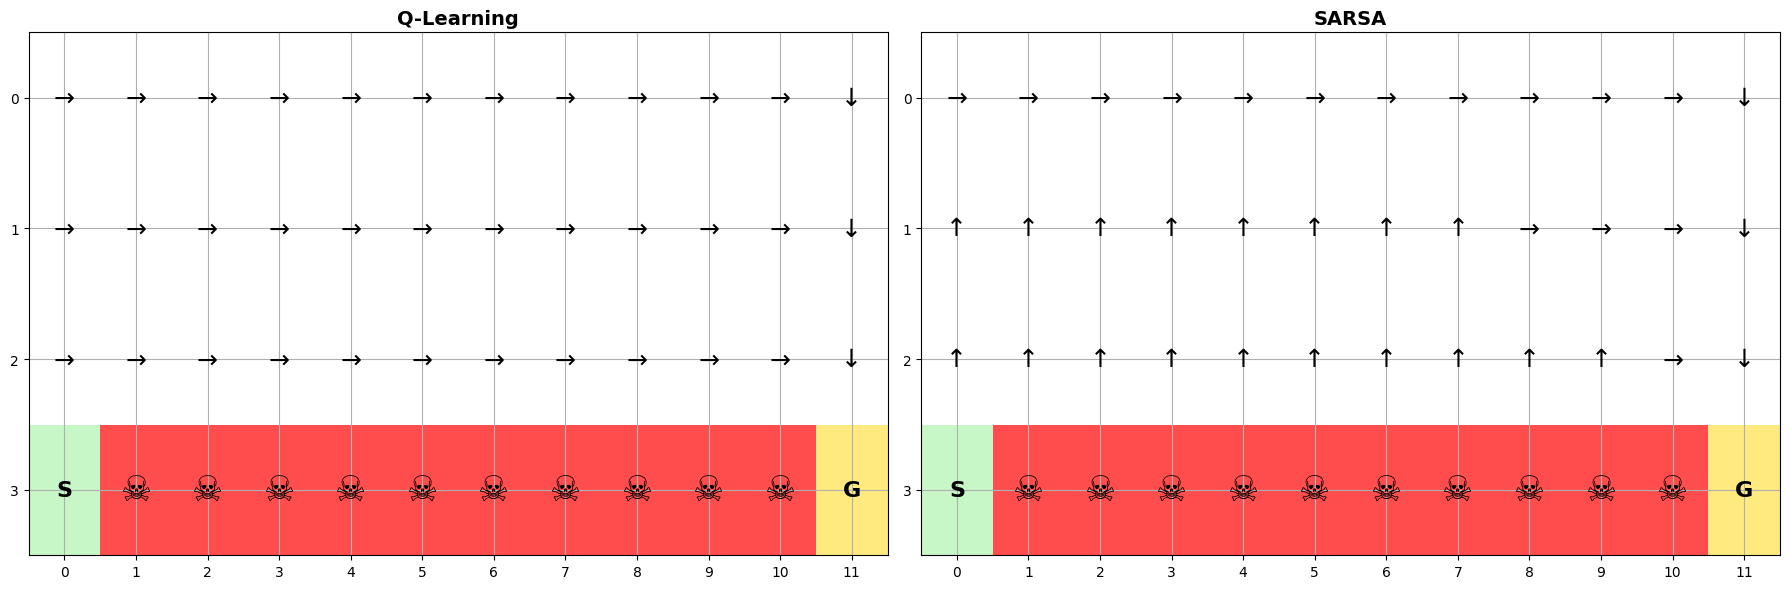

In [9]:
def compare_policies_visual(Qtable_ql, Qtable_sarsa):
    """
    Mostra as políticas lado a lado
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    actions_symbols = ['↑', '→', '↓', '←']

    for ax, Qtable, title in [(ax1, Qtable_ql, "Q-Learning"),
                               (ax2, Qtable_sarsa, "SARSA")]:
        policy = np.argmax(Qtable, axis=1).reshape(4, 12)

        for i in range(4):
            for j in range(12):
                # Start
                if i == 3 and j == 0:
                    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                               facecolor='lightgreen', alpha=0.5))
                    ax.text(j, i, 'S', ha='center', va='center',
                           fontsize=16, fontweight='bold')
                # Goal
                elif i == 3 and j == 11:
                    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                               facecolor='gold', alpha=0.5))
                    ax.text(j, i, 'G', ha='center', va='center',
                           fontsize=16, fontweight='bold')
                # Cliff
                elif i == 3 and 0 < j < 11:
                    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                               facecolor='red', alpha=0.7))
                    ax.text(j, i, '☠', ha='center', va='center', fontsize=25)
                # Normal
                else:
                    ax.text(j, i, actions_symbols[policy[i, j]],
                           ha='center', va='center', fontsize=18)

        ax.set_xlim(-0.5, 11.5)
        ax.set_ylim(-0.5, 3.5)
        ax.set_xticks(range(12))
        ax.set_yticks(range(4))
        ax.grid(True)
        ax.set_title(f'{title}', fontsize=14, fontweight='bold')
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

compare_policies_visual(results_cliff['Qtable_ql'], results_cliff['Qtable_sarsa'])



---


# Q-LEARNING (OFF-POLICY):
```
Q[s,a] ← Q[s,a] + α[R + γ * max Q[s',a'] - Q[s,a]]
#                              ^^^^^^^^^^^
#                        Sempre usa a MELHOR ação possível
#                        (ignora exploração que aconteceu)
```

# SARSA (ON-POLICY):
```
Q[s,a] ← Q[s,a] + α[R + γ * Q[s',a_next] - Q[s,a]]
#                              ^^^^^^^^^^^
#                        Usa a ação que FOI escolhida
#                        (incluindo exploração aleatória!)
```

---

# O Que Aconteceu Durante o Treinamento

## Cenário: Agente na Linha 2 (logo acima do cliff)

### Q-Learning Pensou:


Estado: Linha 2, Coluna 5
Ações possíveis: ↑ ↓ → ←

Exploração (ε-greedy):
- 80% das vezes: → (direita - ótimo!)
- 20% das vezes: ação aleatória
    - Se escolher ↓ → CAI NO CLIFF (-100)!

```
Atualização Q-Learning:
  Q[s, →] ← ... + γ * max(Q[s'])  ← Usa o MELHOR Q possível
  
  Mesmo que tenha caído explorando ↓,
  Q-Learning aprende: "Se eu SEMPRE escolher →, é ótimo!"
  
  Política final: → → → (caminho arriscado)
```

### SARSA Pensou:

Estado: Linha 2, Coluna 5
Ações possíveis: ↑ ↓ → ←

Exploração (ε-greedy):
 - 80% das vezes: → (direita)
 - 20% das vezes: ação aleatória
    - Se escolher ↓ → CAI NO CLIFF (-100)!

```
Atualização SARSA:
  Q[s, →] ← ... + γ * Q[s', a_next]  ← Usa a ação que FOI escolhida
  
  Se a_next foi ↓ (exploração):
    Q[s, →] recebe penalidade porque próxima ação foi ruim!
  
  SARSA aprende: "Mesmo → sendo boa, o que vem depois é arriscado!"
  
  Solução: ↑ ↑ ↑ (sobe para linha 0 - mais seguro!)
  Política final: Sobe para o topo
```

---

##  Intuição Profunda

### Q-Learning (Otimista):
- **Assume**: "Sempre vou escolher perfeitamente no futuro"
- **Aprende**: Política ótima (assumindo execução perfeita)
- **Resultado**: Caminho curto, mas perigoso se houver exploração

### SARSA (Realista):
- **Assume**: "Vou continuar explorando (ε-greedy) no futuro"
- **Aprende**: Política segura considerando a exploração
- **Resultado**: Caminho longo, mas seguro mesmo com exploração

---

## Analogia do Mundo Real

Imagine você tem um carro autônomo treinado com Q-Learnig e com SARSA:

### 🔵 Carro autônomo com o Q-Learning:
```
"Veja, se você dirigir PERFEITAMENTE colado na beirada,
 economiza 10 minutos! É o caminho ótimo!"

[Mas na prática, você pode errar e cair...]
```

### 🟠 Carro autônomo com o SARSA:
```
"Você ainda está aprendendo e pode errar.
 Melhor ir pelo meio da estrada, longe da beirada.
 Demora mais 5 minutos, mas é muito mais seguro!"

[Caminho seguro considerando que você pode errar]
```

---


Q-LEARNING (Off-Policy):
```
┌───────────────┐
│   LINHA 0     │  ← Nunca passa aqui
├───────────────┤
│   LINHA 1     │  ← Nunca passa aqui
├───────────────┤
│ S→→→→→→→→→→→→ │  ← Passa aqui (arriscado!)
├───────────────┤
│ ☠☠☠☠☠☠☠☠☠☠☠G  │
└───────────────┘
```
14 passos - ÓTIMO mas ARRISCADO

SARSA (On-Policy):
```
┌───────────────┐
│ →→→→→→→→→→→↓  │  ← Passa aqui (seguro!)
├───────────────┤
│ ↑           ↓ │
├───────────────┤
│ ↑           ↓ │
├───────────────┤
│ S☠☠☠☠☠☠☠☠☠☠G  │
└───────────────┘
```
18 passos - SEGURO mas SUBÓTIMO